Projeto: Prevendo a evasão de clientes

Missão

Sua nova missão é desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços.

A empresa quer antecipar o problema da evasão, e cabe a você construir um pipeline robusto para essa etapa inicial de modelagem

 Objetivos do Desafio

- Preparar os dados para a modelagem (tratamento, encoding, normalização).

- Realizar análise de correlação e seleção de variáveis.

- Treinar dois ou mais modelos de classificação.

- Avaliar o desempenho dos modelos com métricas.

- Interpretar os resultados, incluindo a importância das variáveis.

- Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

<h1><font color="blue">Extração</font></h1>

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

In [38]:
dados = pd.read_csv('/content/dados_previsao.csv')
dados.head(2)

,customerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ContasDiarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667


In [39]:
dados.columns

Index(['customerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly', 'ChargesTotal',
       'ContasDiarias'],
      dtype='object')

In [40]:
valor_colunas = dados.nunique()
valor_colunas

,0
customerID,7043
Churn,2
Gender,2
SeniorCitizen,2
Partner,2
Dependents,2
Tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [41]:
print(dados['Churn'].unique())
print(dados['Gender'].unique())
print(dados['SeniorCitizen'].unique())
print(dados['Partner'].unique())
print(dados['Dependents'].unique())
print(dados['PhoneService'].unique())
print(dados['MultipleLines'].unique())
print(dados['InternetService'].unique())
print(dados['OnlineSecurity'].unique())
print(dados['OnlineBackup'].unique())
print(dados['DeviceProtection'].unique())
print(dados['TechSupport'].unique())
print(dados['StreamingTV'].unique())
print(dados['StreamingMovies'].unique())
print(dados['Contract'].unique())
print(dados['PaperlessBilling'].unique())
print(dados['PaymentMethod'].unique())





['No' 'Yes']
['Female' 'Male']
[0 1]
['Yes' 'No']
['Yes' 'No']
['Yes' 'No']
['No' 'Yes' 'No phone service']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['One year' 'Month-to-month' 'Two year']
['Yes' 'No']
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [42]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [43]:
dados.nunique()

,0
customerID,7043
Churn,2
Gender,2
SeniorCitizen,2
Partner,2
Dependents,2
Tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [44]:
col = {
    col: dados[col].unique().tolist()
    for col in dados.columns
    if dados[col].nunique() == 3
}

col

{'MultipleLines': ['No', 'Yes', 'No phone service'],
 'InternetService': ['DSL', 'Fiber optic', 'No'],
 'OnlineSecurity': ['No', 'Yes', 'No internet service'],
 'OnlineBackup': ['Yes', 'No', 'No internet service'],
 'DeviceProtection': ['No', 'Yes', 'No internet service'],
 'TechSupport': ['Yes', 'No', 'No internet service'],
 'StreamingTV': ['Yes', 'No', 'No internet service'],
 'StreamingMovies': ['No', 'Yes', 'No internet service'],
 'Contract': ['One year', 'Month-to-month', 'Two year']}

<h1><font color="blue">Tratamento dos dados</font></h1>

In [45]:
dados = dados.drop(columns=['customerID'])
dados.head(1)



,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ContasDiarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667


### Transformando No Internet service em No

In [46]:
col_agrupadas = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in col_agrupadas:
    dados[col_agrupadas] = dados[col_agrupadas].replace({'No internet service': 'No'})

In [47]:
dados['MultipleLines'] = dados['MultipleLines'].replace({'No phone service': 'No'})


In [48]:
dados['SeniorCitizen'] = dados['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

###Analisando a correlação das variaveis numericas com Churn

In [49]:
var_numericas = dados.select_dtypes(include=["int64", "float64"])




In [50]:
var_numericas['Churn'] = dados['Churn'].map({'No': 0, 'Yes': 1})
var_numericas.head(1)

,Tenure,ChargesMonthly,ChargesTotal,ContasDiarias,Churn
0,9,65.6,593.3,2.186667,0


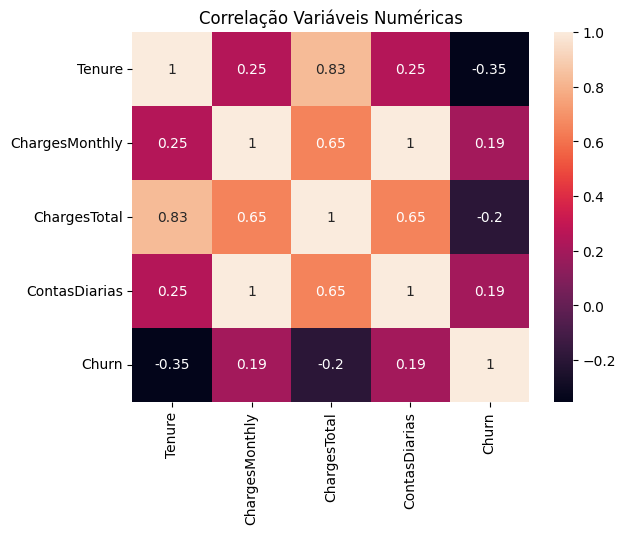

In [51]:
#correlação

correlacao = var_numericas.corr()

sns.heatmap(correlacao, annot=True)
plt.title("Correlação Variáveis Numéricas")
plt.show()

###Analisando Qui-quadrado, p_value, grau de significancia




In [52]:
var_categoricas = dados.select_dtypes(include=["object"])

In [53]:
var_categoricas['Churn'] = dados['Churn'].map({'No': 0, 'Yes': 1})
var_categoricas.head(1)

,Churn,Gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,Female,No,Yes,Yes,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check


In [54]:
from scipy.stats import chi2_contingency

resultados = []

for col in var_categoricas:
    tabela = pd.crosstab(dados[col], dados['Churn'])
    chi2, p, dof, expected = chi2_contingency(tabela)

    observado = tabela.values

    chi2_manual = ((observado - expected) ** 2 / expected).sum()

    resultados.append({
        'Variavel': col,
        'Qui_Quadrado': chi2_manual,
        'p_value': p,
        'Graus_de_Liberdade': dof
    })

    resultado_qui = pd.DataFrame(resultados)
    resultado_qui['p_value'] = resultado_qui['p_value'].round(3)

    resultado_qui = resultado_qui.sort_values(by='Qui_Quadrado', ascending=False)
    resultado_qui.reset_index(drop=True, inplace=True)

resultado_qui

,Variavel,Qui_Quadrado,p_value,Graus_de_Liberdade
0,Churn,7043.000000,0.000,1
1,Contract,1184.596572,0.000,2
2,InternetService,732.309590,0.000,2
3,PaymentMethod,648.142327,0.000,3
4,PaperlessBilling,259.160974,0.000,1
5,OnlineSecurity,206.489794,0.000,1
6,TechSupport,190.987707,0.000,1
7,Dependents,189.940334,0.000,1
8,SeniorCitizen,160.352132,0.000,1
9,Partner,159.414528,0.000,1


O teste Qui-Quadrado indicou associação estatisticamente significativa (p < 0.001) entre churn e as variáveis Contract, InternetService, PaymentMethod, PaperlessBilling, Partner, Dependents, OnlineSecurity e TechSupport.
Não foi observada associação significativa para Gender e PhoneService (p > 0.05).

###Analisando a proporção do churn em relação as variaveis categoricas

In [55]:
categorias = var_categoricas.drop(columns=['Churn'])
for col in categorias:
    print(f"\n ➜ Variável: {col}")
    display(pd.crosstab(dados[col],dados['Churn'],normalize='index') * 100)



 ➜ Variável: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 ➜ Variável: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 ➜ Variável: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 ➜ Variável: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 ➜ Variável: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


<Figure size 500x200 with 0 Axes>

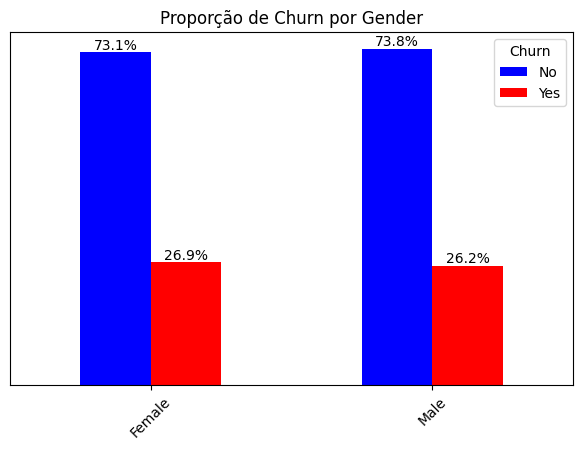

<Figure size 500x200 with 0 Axes>

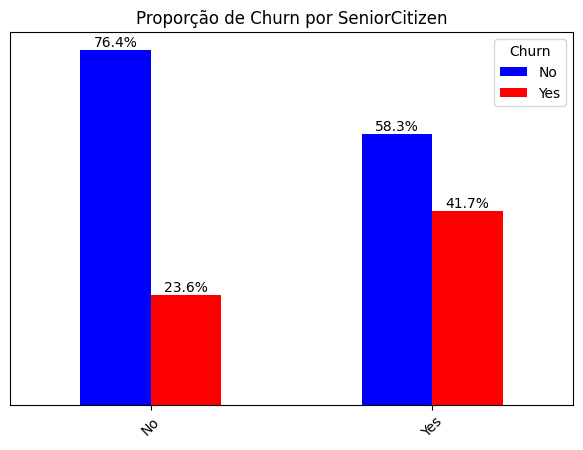

<Figure size 500x200 with 0 Axes>

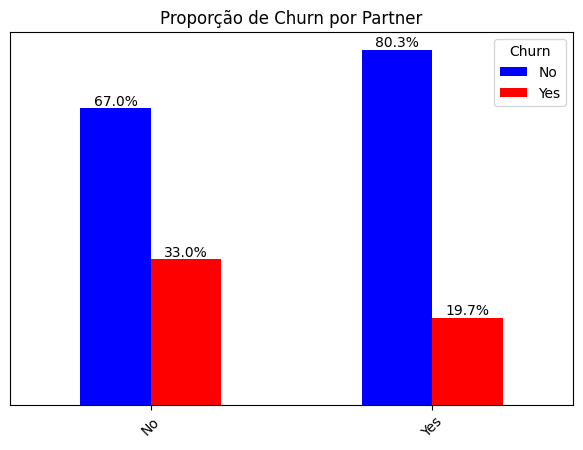

<Figure size 500x200 with 0 Axes>

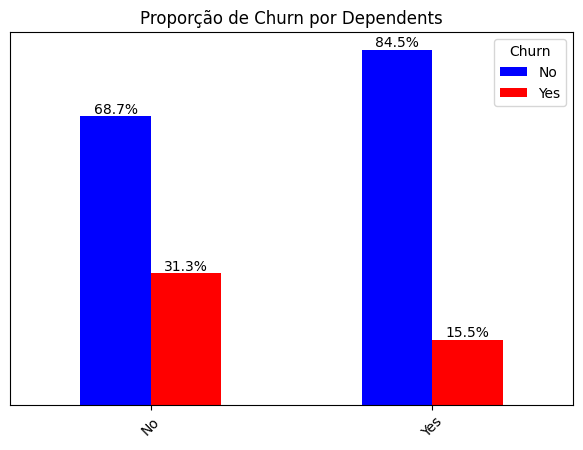

<Figure size 500x200 with 0 Axes>

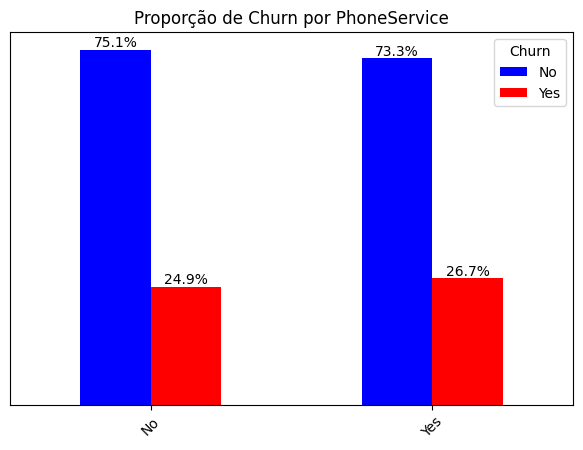

<Figure size 500x200 with 0 Axes>

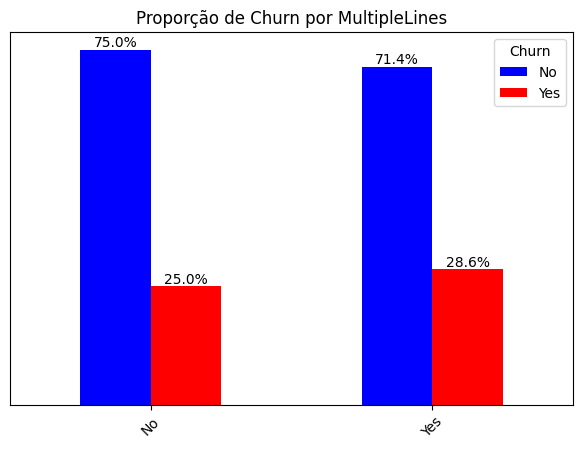

<Figure size 500x200 with 0 Axes>

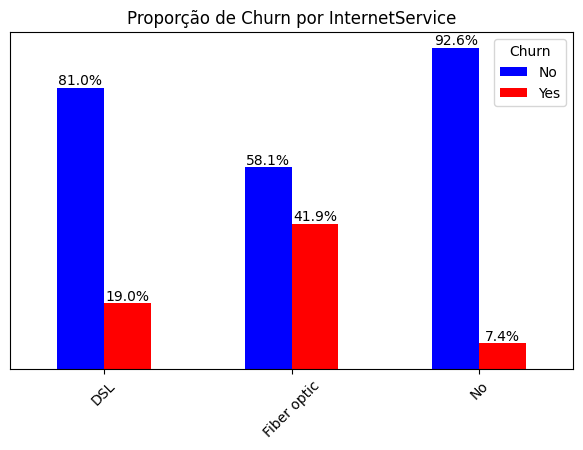

<Figure size 500x200 with 0 Axes>

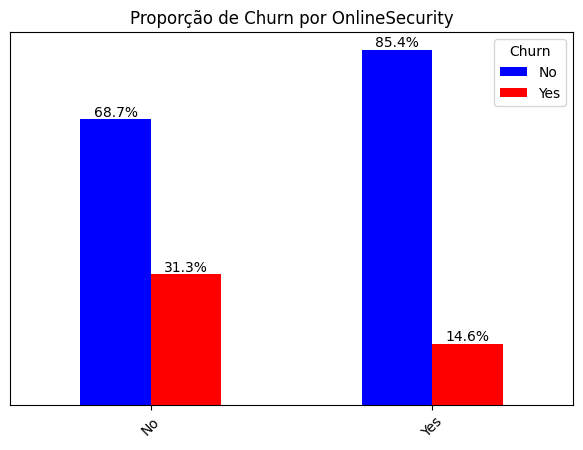

<Figure size 500x200 with 0 Axes>

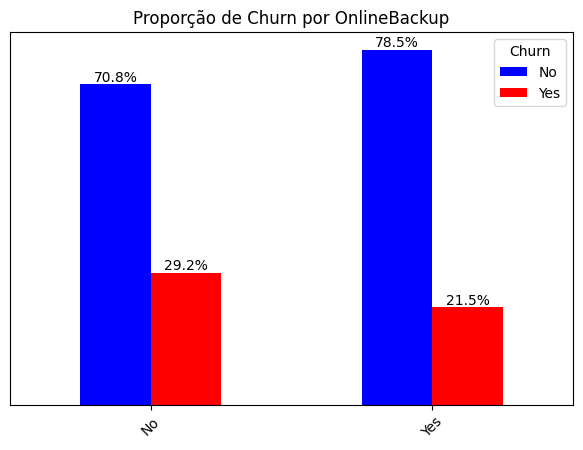

<Figure size 500x200 with 0 Axes>

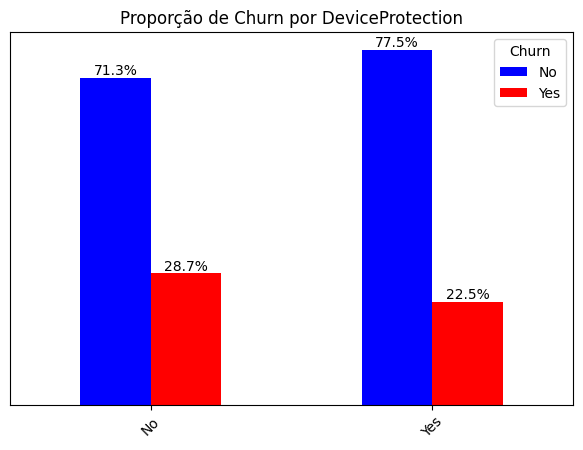

<Figure size 500x200 with 0 Axes>

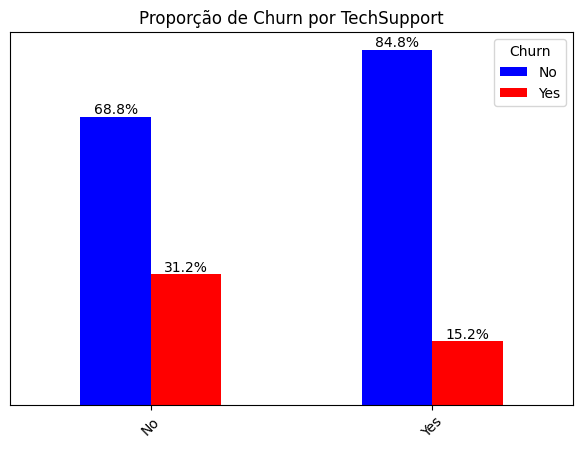

<Figure size 500x200 with 0 Axes>

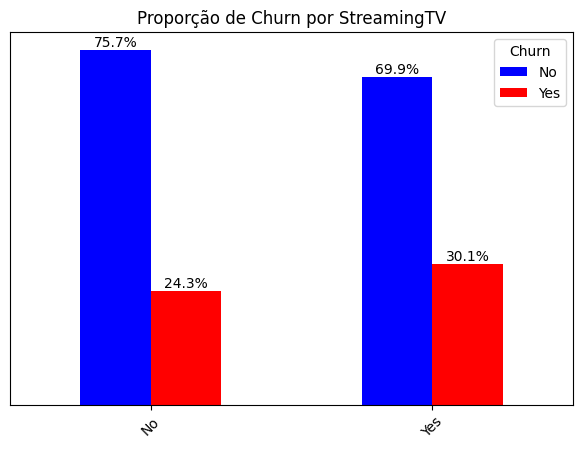

<Figure size 500x200 with 0 Axes>

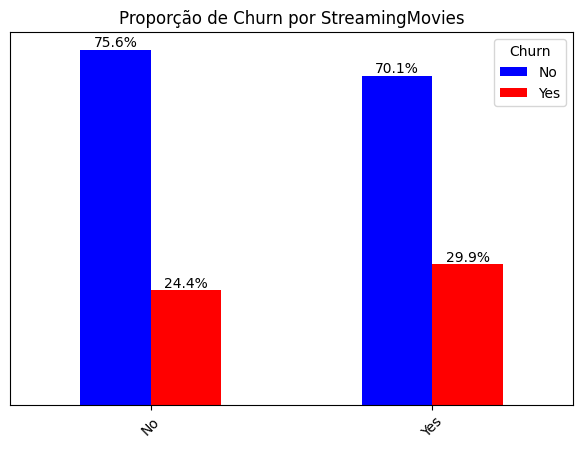

<Figure size 500x200 with 0 Axes>

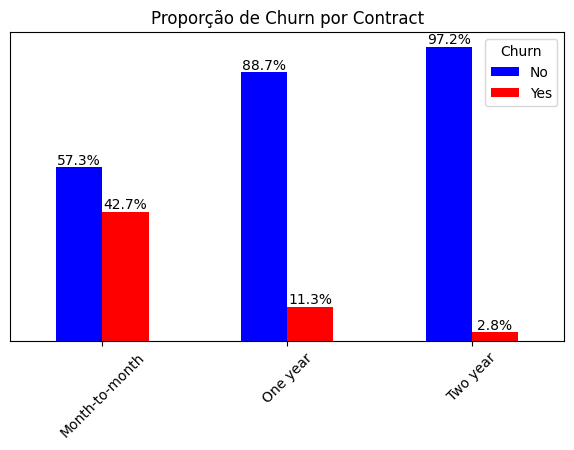

<Figure size 500x200 with 0 Axes>

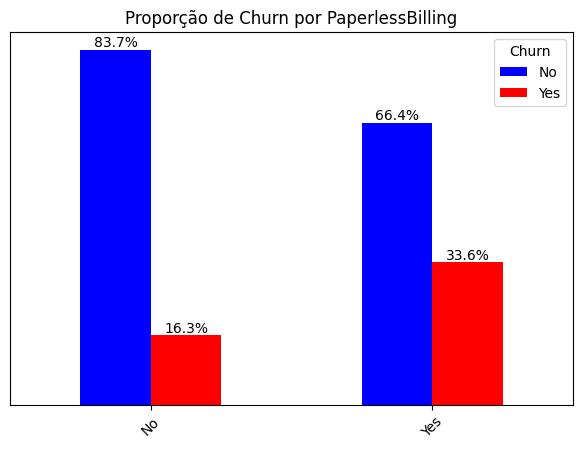

<Figure size 500x200 with 0 Axes>

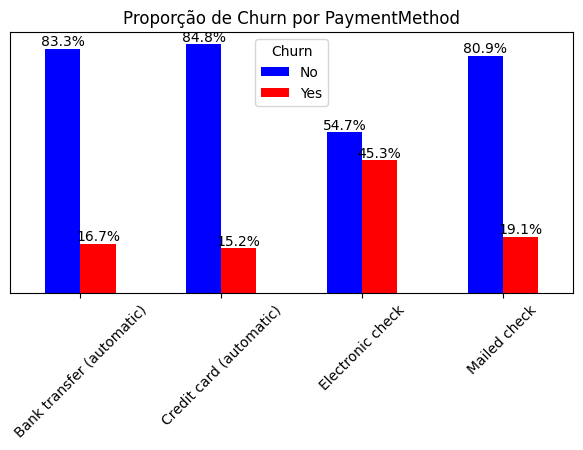

In [56]:
import matplotlib.pyplot as plt
cores = ['Blue','Red']
for col in categorias:
    plt.figure(figsize=(5,2))

    tabela = pd.crosstab(dados[col], dados['Churn'], normalize='index') * 100
    ax = tabela.plot(kind='bar',color=cores)
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.title(f"Proporção de Churn por {col}")
    plt.ylabel("Percentual (%)")

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge')

    plt.legend(title='Churn')
    plt.tight_layout()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticks([])
    plt.show()




In [57]:
dados.head(1)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ContasDiarias
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667


In [58]:
dados[['ChargesMonthly', 'ChargesTotal', 'ContasDiarias']].corr()

,ChargesMonthly,ChargesTotal,ContasDiarias
ChargesMonthly,1.000000,0.651174,1.000000
ChargesTotal,0.651174,1.000000,0.651174
ContasDiarias,1.000000,0.651174,1.000000


In [59]:
#excluinido as colunas gender e phone service segundo o resultado do qui quadrado não apresentou associação significativa
#as colunas charges total porque ja tenho a tenure e contas diarias devido multicolinearidade com a charges monthly

dados = dados.drop(columns=['Gender','PhoneService', 'ChargesTotal','ContasDiarias'], errors='ignore')
dados.head(1)

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6


In [60]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  ChargesMonthly    7043 non-null   float64


#Definindo variaveis alvo e variaveis explicativa

In [61]:
x = dados.drop(columns=['Churn'])
y = dados['Churn']

In [62]:
x

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [63]:
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


# Transformando variaveis categoricas em numericas

In [64]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [65]:
colunas = x.columns
colunas

Index(['SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly'],
      dtype='object')

In [66]:
for col in x.select_dtypes(include='object').columns:
    print(f"Column '{col}': {x[col].nunique()} unique values")

Column 'SeniorCitizen': 2 unique values
Column 'Partner': 2 unique values
Column 'Dependents': 2 unique values
Column 'MultipleLines': 2 unique values
Column 'InternetService': 3 unique values
Column 'OnlineSecurity': 2 unique values
Column 'OnlineBackup': 2 unique values
Column 'DeviceProtection': 2 unique values
Column 'TechSupport': 2 unique values
Column 'StreamingTV': 2 unique values
Column 'StreamingMovies': 2 unique values
Column 'Contract': 3 unique values
Column 'PaperlessBilling': 2 unique values
Column 'PaymentMethod': 4 unique values


In [67]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','InternetService','Contract','PaymentMethod']
),
    remainder = 'passthrough',
    sparse_threshold=0)

In [68]:
x = one_hot.fit_transform(x)

In [69]:
pd.DataFrame(x, columns = one_hot.get_feature_names_out(colunas))

,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,onehotencoder__TechSupport_Yes,onehotencoder__StreamingTV_Yes,onehotencoder__StreamingMovies_Yes,...,onehotencoder__InternetService_No,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,9.0,65.60
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.90
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,73.90
3,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,98.00
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,13.0,55.15
7039,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,22.0,85.10
7040,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,50.30
7041,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,67.0,67.85


#Transformar variavel alvo

In [70]:
from sklearn.preprocessing import LabelEncoder

In [71]:
label_ecoder = LabelEncoder()

In [72]:
y = label_ecoder.fit_transform(y)

In [73]:
y

array([0, 0, 1, ..., 0, 0, 0])

#Divisão Treino e Teste

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_teste, X_treino, y_teste, y_treino = train_test_split(x,y,stratify=y,random_state=42)


# Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [77]:
modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_treino, y_treino)

y_pred_rf = modelo_rf.predict(X_teste)

report = classification_report(y_teste, y_pred_rf, output_dict=True)

df_report = pd.DataFrame(report).transpose()

df_report.round(3)

,precision,recall,f1-score,support
0,0.823,0.896,0.858,3880.000
1,0.619,0.467,0.532,1402.000
accuracy,0.782,0.782,0.782,0.782
macro avg,0.721,0.682,0.695,5282.000
weighted avg,0.769,0.782,0.772,5282.000


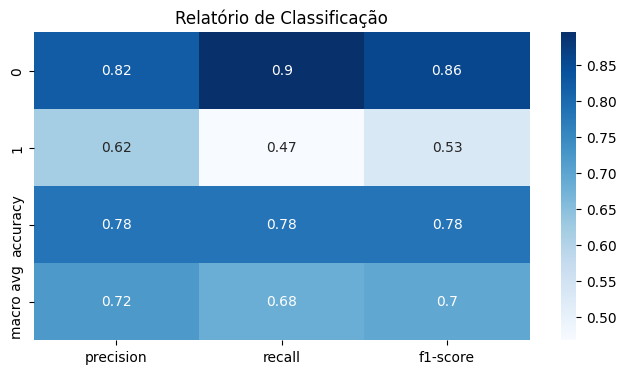

In [78]:
plt.figure(figsize=(8,4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="Blues")
plt.title("Relatório de Classificação")
plt.show()

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [80]:
pd.Series(y).value_counts(normalize=True) * 100

,proportion
0,73.463013
1,26.536987


#Balanceamento dos dados

In [81]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_treino_bal, y_treino_bal = ros.fit_resample(X_treino, y_treino)

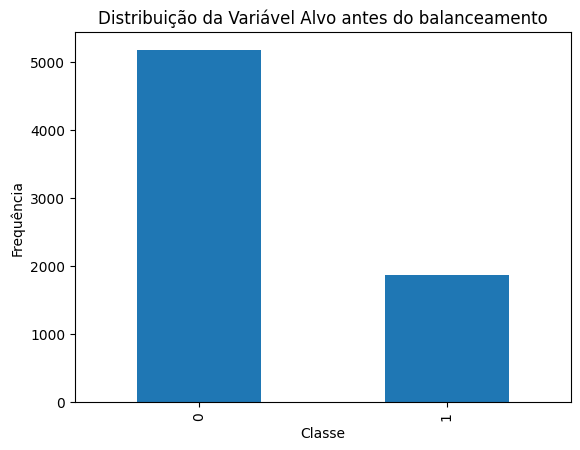

In [82]:
pd.Series(y).value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Alvo antes do balanceamento')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()


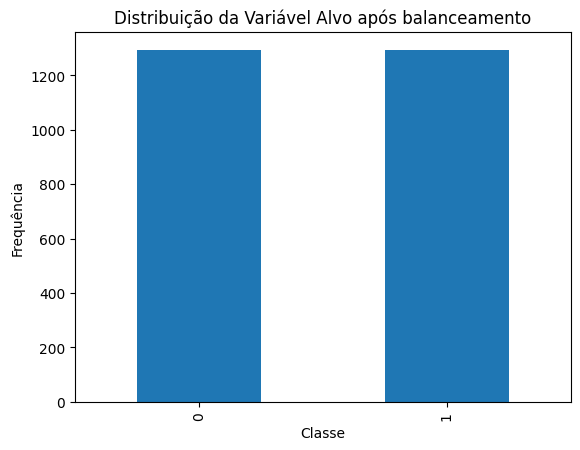

In [83]:
pd.Series(y_treino_bal).value_counts().plot(kind='bar')
plt.title('Distribuição da Variável Alvo após balanceamento')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()

#Normalização dos dados

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [85]:
scaler = StandardScaler()

X_treino_norm = scaler.fit_transform(X_treino)
X_teste_norm = scaler.transform(X_teste)


In [86]:
modelo_lr = LogisticRegression()

modelo_lr.fit(X_treino_norm, y_treino)

y_pred_lr = modelo_lr.predict(X_teste_norm)

report_lr = classification_report(y_teste, y_pred_lr, output_dict=True)

df_report_lr = pd.DataFrame(report_lr).transpose()

df_report_lr

,precision,recall,f1-score,support
0,0.843085,0.898711,0.870010,3880.000000
1,0.657068,0.537090,0.591052,1402.000000
accuracy,0.802726,0.802726,0.802726,0.802726
macro avg,0.750077,0.717901,0.730531,5282.000000
weighted avg,0.793711,0.802726,0.795966,5282.000000


#Importância das variáveis

###Random Forest

In [87]:
nomes_colunas = one_hot.get_feature_names_out()

importancia = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Importancia': modelo_rf.feature_importances_
})

importancia = importancia.sort_values(by='Importancia', ascending=False)

importancia

,Variavel,Importancia
22,remainder__ChargesMonthly,0.232573
21,remainder__Tenure,0.220002
14,onehotencoder__Contract_Month-to-month,0.055558
12,onehotencoder__InternetService_Fiber optic,0.038601
19,onehotencoder__PaymentMethod_Electronic check,0.034349
4,onehotencoder__OnlineSecurity_Yes,0.033590
10,onehotencoder__PaperlessBilling_Yes,0.033278
1,onehotencoder__Partner_Yes,0.030200
0,onehotencoder__SeniorCitizen_Yes,0.027285
5,onehotencoder__OnlineBackup_Yes,0.027249


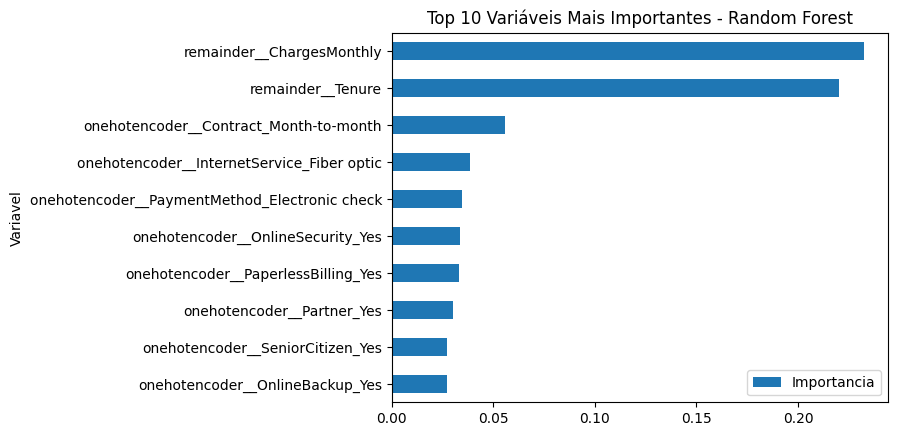

In [88]:
import matplotlib.pyplot as plt

importancia.head(10).plot(
    x='Variavel',
    y='Importancia',
    kind='barh'
)

plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.gca().invert_yaxis()
plt.show()

###Regressão Logistica

In [89]:
coeficientes = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes

,Variavel,Coeficiente
12,onehotencoder__InternetService_Fiber optic,0.619251
9,onehotencoder__StreamingMovies_Yes,0.316653
14,onehotencoder__Contract_Month-to-month,0.298289
8,onehotencoder__StreamingTV_Yes,0.208369
3,onehotencoder__MultipleLines_Yes,0.151636
0,onehotencoder__SeniorCitizen_Yes,0.135262
10,onehotencoder__PaperlessBilling_Yes,0.089680
19,onehotencoder__PaymentMethod_Electronic check,0.070646
1,onehotencoder__Partner_Yes,0.046794
15,onehotencoder__Contract_One year,0.024747


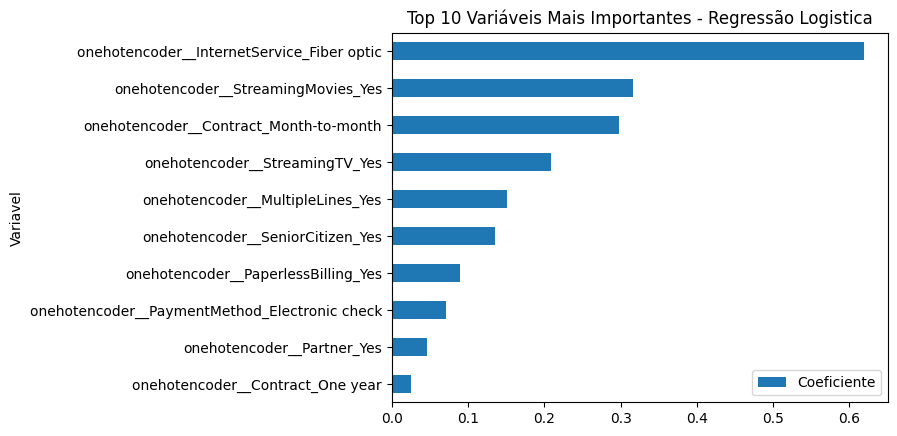

In [90]:
coeficientes.head(10).plot(
    x='Variavel',
    y='Coeficiente',
    kind='barh'
)

plt.title('Top 10 Variáveis Mais Importantes - Regressão Logistica')
plt.gca().invert_yaxis()
plt.show()

Análise de Importância das Variáveis

Após o treinamento dos modelos, foi realizada a análise das variáveis mais relevantes para a previsão de evasão de clientes.

No modelo Random Forest, a importância das variáveis foi calculada com base na contribuição de cada variável para a redução da impureza nas árvores de decisão. As variáveis mais relevantes identificadas foram relacionadas ao tempo de permanência do cliente, tipo de contrato e valor mensal pago.

Já no modelo Regressão Logística, os coeficientes das variáveis foram analisados para identificar seu impacto na probabilidade de churn. Coeficientes positivos indicam aumento na probabilidade de cancelamento, enquanto coeficientes negativos indicam maior retenção de clientes.

Análise de Importância das Variáveis

Após o treinamento dos modelos, foi realizada a análise das variáveis mais relevantes para a previsão de evasão de clientes.

No modelo Random Forest, a importância das variáveis foi calculada com base na contribuição de cada variável para a redução da impureza nas árvores de decisão. As variáveis mais relevantes identificadas foram relacionadas ao tempo de permanência do cliente, tipo de contrato e valor mensal pago.

Já no modelo Regressão Logística, os coeficientes das variáveis foram analisados para identificar seu impacto na probabilidade de churn. Coeficientes positivos indicam aumento na probabilidade de cancelamento, enquanto coeficientes negativos indicam maior retenção de clientes.

# treinando um novo modelo

In [91]:
coeficientes

,Variavel,Coeficiente
12,onehotencoder__InternetService_Fiber optic,0.619251
9,onehotencoder__StreamingMovies_Yes,0.316653
14,onehotencoder__Contract_Month-to-month,0.298289
8,onehotencoder__StreamingTV_Yes,0.208369
3,onehotencoder__MultipleLines_Yes,0.151636
0,onehotencoder__SeniorCitizen_Yes,0.135262
10,onehotencoder__PaperlessBilling_Yes,0.089680
19,onehotencoder__PaymentMethod_Electronic check,0.070646
1,onehotencoder__Partner_Yes,0.046794
15,onehotencoder__Contract_One year,0.024747


In [92]:
nomes_colunas = one_hot.get_feature_names_out()

In [93]:
X = pd.DataFrame(x, columns=nomes_colunas)
X

,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,onehotencoder__TechSupport_Yes,onehotencoder__StreamingTV_Yes,onehotencoder__StreamingMovies_Yes,...,onehotencoder__InternetService_No,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,9.0,65.60
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.90
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,73.90
3,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,98.00
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,13.0,55.15
7039,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,22.0,85.10
7040,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,50.30
7041,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,67.0,67.85


In [94]:
variaveis_top8 = [
'onehotencoder__InternetService_Fiber optic',
'onehotencoder__StreamingMovies_Yes',
'onehotencoder__Contract_Month-to-month',
'onehotencoder__StreamingTV_Yes',
'onehotencoder__MultipleLines_Yes',
'onehotencoder__SeniorCitizen_Yes',
'onehotencoder__PaperlessBilling_Yes',
'onehotencoder__PaymentMethod_Electronic check'
]

In [95]:
X_reduzido = X[variaveis_top8]

In [96]:
from sklearn.model_selection import train_test_split

X_treino2, X_teste2, y_treino2, y_teste2 = train_test_split(
    X_reduzido, y, test_size=0.25, random_state=42
)

In [97]:
modelo_lr2 = LogisticRegression()

modelo_lr2.fit(X_treino2, y_treino2)

y_pred2 = modelo_lr2.predict(X_teste2)

In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [99]:
acuracia = accuracy_score(y_teste2, y_pred2)
precisao = precision_score(y_teste2, y_pred2)
recall = recall_score(y_teste2, y_pred2)
f1 = f1_score(y_teste2, y_pred2)

In [100]:
metricas_modelo_2 = pd.DataFrame({
    'Acuracia':[accuracy_score(y_teste2, y_pred2)],
    'Precision':[precision_score(y_teste2, y_pred2)],
    'Recall':[recall_score(y_teste2, y_pred2)],
    'F1-score':[f1_score(y_teste2, y_pred2)]
})

metricas_modelo_2

,Acuracia,Precision,Recall,F1-score
0,0.771721,0.585294,0.432609,0.4975


In [101]:
acuracia1 = accuracy_score(y_teste, y_pred_lr)
precisao1 = precision_score(y_teste, y_pred_lr)
recall1 = recall_score(y_teste, y_pred_lr)
f1_1= f1_score(y_teste, y_pred_lr)

In [102]:
metricas_modelo_1 = pd.DataFrame({
    'Acuracia1':[ accuracy_score(y_teste, y_pred_lr)],
    'Precision1':[precision_score(y_teste, y_pred_lr)],
    'Recall1':[recall_score(y_teste, y_pred_lr)],
    'F1-score1':[ f1_score(y_teste, y_pred_lr)]
})

metricas_modelo_1

,Acuracia1,Precision1,Recall1,F1-score1
0,0.802726,0.657068,0.53709,0.591052


In [103]:
dados.head(1)

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6


In [104]:
dados.to_csv('dados_tratados.csv', index=False)

<h1><font color="blue">Relatório de Análise de Evasão de Clientes (Churn) – TelecomX</font></h1>

## **Objetivo da Análise**

O objetivo deste projeto foi identificar os principais fatores que influenciam a evasão de clientes (Churn) na empresa de telecomunicações Telecom X.

A partir da análise exploratória e da aplicação de modelos de Machine Learning, buscou-se compreender quais características dos clientes aumentam a probabilidade de cancelamento do serviço e propor estratégias de retenção baseadas em dados.

Foi desenvolvido modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços e a partir disso e antecipar o problema da evasão.


## **Preparação e Tratamento dos Dados**

Inicialmente, foi realizada a importação da base de dados contendo informações demográficas, características dos serviços contratados e dados de faturamento dos clientes.

**As principais etapas de preparação dos dados incluíram:**

- Verificação de valores únicos em cada variável

- Tratamento de valores ausentes

- Conversão de variáveis categóricas utilizando One-Hot Encoding

- Exclusão de variáveis que não eram relevantes para o modelo, que não apresentaram associação significativa

- Exclusão das variáveis devido multicolinearidade

- Transformação das colunas categoricas em numericas

- Separação entre variáveis explicativas (X) e variável alvo (Churn)

- Divisão da base em treino e teste

- Balanceamento da classe utilizando RandomOverSampler, devido ao desbalanceamento entre clientes que cancelaram e os que permaneceram

Essa preparação foi essencial para melhorar o desempenho dos modelos e garantir análises mais confiáveis.

## **Modelos Utilizados**

Foram desenvolvidos dois modelos para prever a evasão de clientes (churn): Random Forest e Logistic Regression


### **Random Forest**

O segundo modelo utilizado foi o Random Forest, um algoritmo baseado em múltiplas árvores de decisão que melhora a capacidade de generalização e reduz o risco de overfitting.

Esse modelo permitiu identificar a importância relativa das variáveis, mostrando quais fatores mais influenciam na previsão de cancelamento.

Após o treinamento do modelo, foram avaliadas as métricas:

- Acurácia

- Precisão

- Recall

- F1-score



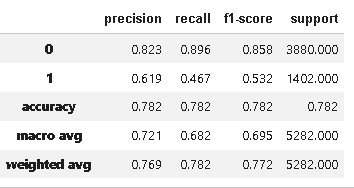

O modelo Random Forest apresentou acurácia de 78,2%, indicando que a maioria das previsões foi correta. Ele demonstrou bom desempenho na identificação de clientes que não cancelam o serviço, com recall de 0,896 para essa classe.

Entretanto, para a classe de clientes que cancelam o serviço, o modelo apresentou recall de 0,466, indicando dificuldade em identificar corretamente todos os clientes com risco de evasão. O F1-score de 0,532 para essa classe também sugere um desempenho moderado.

###  **Regressão Logistica**

Esse modelo permitiu identificar a importância relativa das variáveis, mostrando quais fatores mais influenciam na previsão de cancelamento. A Regressão Logística é um modelo estatístico amplamente utilizado em problemas de classificação binária. Neste estudo, ela foi aplicada para estimar a probabilidade de um cliente cancelar o serviço.

Após o treinamento do modelo, foram avaliadas as métricas:

- Acurácia

- Precisão

- Recall

- F1-score

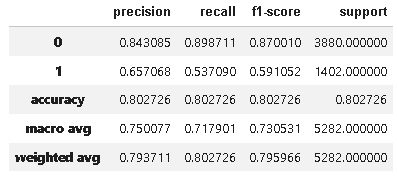

O modelo de Regressão Logística apresentou acurácia de 80,3%, superando o Random Forest. Além disso, demonstrou melhor capacidade de identificar clientes que cancelam o serviço, com recall de 0,537 e F1-score de 0,591 para a classe de churn.

Esse resultado indica um melhor equilíbrio entre precisão e recall, tornando o modelo mais eficiente para detectar clientes com risco de evasão.

Além disso, foram analisados os coeficientes das variáveis, que indicam o impacto de cada característica na probabilidade de churn.

Coeficiente do modelo Random Forest

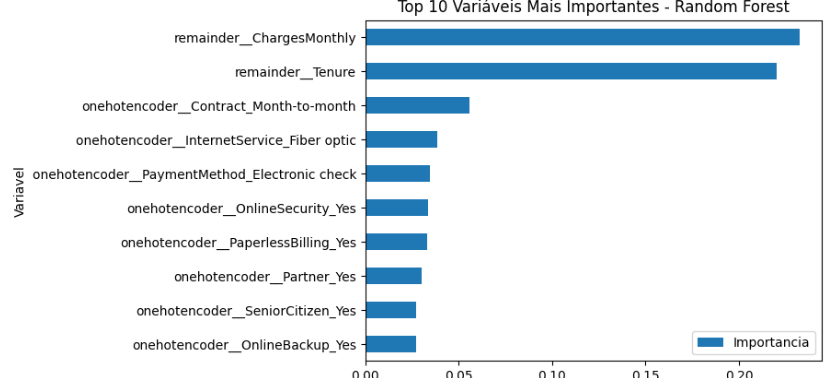

Coeficiente do modelo Regressão Logistica

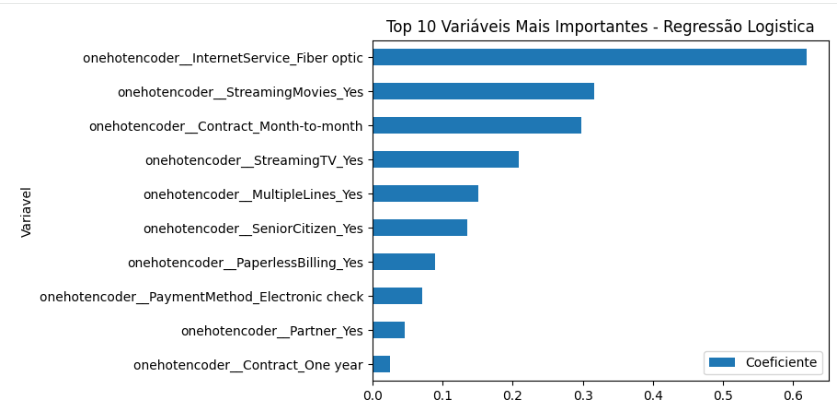

.

## **Principais Fatores que Influenciam o Churn**

Com base na análise dos coeficientes da Regressão Logística e na importância das variáveis no Random Forest, foram identificados alguns fatores com forte influência na evasão de clientes.

- Tipo de Contrato

Clientes com contrato mensal (Month-to-month) apresentam maior probabilidade de cancelar o serviço.

Isso ocorre porque esse tipo de contrato oferece maior flexibilidade para encerramento, diferente de contratos anuais ou de dois anos.

Impacto:
Clientes com contrato mensal apresentam maior risco de churn.

- Tempo de Permanência (Tenure)

Clientes com baixo tempo de permanência na empresa tendem a cancelar o serviço com maior frequência.

Clientes que permanecem mais tempo geralmente já passaram da fase inicial de adaptação e estão mais satisfeitos com o serviço.

Impacto:
Clientes novos possuem maior probabilidade de evasão.

-  Valor da Mensalidade (Monthly Charges)

Valores mais altos de mensalidade estão associados a uma maior taxa de cancelamento.

Isso pode indicar que clientes com custos elevados são mais sensíveis a preço ou comparam mais frequentemente com concorrentes.

Impacto:
Mensalidades altas aumentam a probabilidade de churn.

- Serviços de Suporte (TechSupport e OnlineSecurity)

Clientes que não possuem serviços adicionais de suporte técnico ou segurança online apresentam maior tendência a cancelar.

Esses serviços agregam valor ao pacote e aumentam a dependência do cliente com a empresa.

Impacto:
A ausência desses serviços aumenta o risco de evasão.

- Tipo de Internet

Clientes que utilizam fibra óptica (Fiber Optic) frequentemente apresentam maior churn em comparação com outros tipos de conexão.

Isso pode estar relacionado ao custo mais elevado ou expectativas maiores de qualidade.

- Forma de Pagamento

Clientes que utilizam pagamento por cheque eletrônico (Electronic Check) costumam apresentar maior taxa de cancelamento.

Isso pode indicar menor fidelização ou menor automação no pagamento.

## **Comparação do Desempenho dos Modelos**

Os modelos foram avaliados utilizando as seguintes métricas:

- Acurácia – proporção de previsões corretas

- Precisão – proporção de previsões positivas corretas

- Recall – capacidade do modelo identificar clientes que realmente cancelam

- F1-score – equilíbrio entre precisão e recall

Resultados Observados

A Regressão Logística apresentou boa interpretabilidade e permitiu entender o impacto das variáveis.

O Random Forest apresentou melhor capacidade de capturar relações não lineares e identificar variáveis mais relevantes.

Em geral, o Random Forest tende a apresentar melhor desempenho preditivo, enquanto a Regressão Logística oferece maior interpretabilidade.

Com base nas métricas analisadas, o modelo de Regressão Logística mostrou-se mais adequado para o problema de previsão de evasão de clientes, pois apresenta melhor desempenho na identificação de clientes com maior probabilidade de cancelamento. Esse resultado é relevante para estratégias de retenção, permitindo que a empresa identifique e atue preventivamente sobre clientes com risco de evasão

## **Estratégias de Retenção de Clientes**

Com base nos fatores identificados, algumas estratégias podem ser implementadas para reduzir a evasão.

- Incentivar contratos de longo prazo

- Oferecer benefícios para clientes que optarem por contratos anuais ou de dois anos, como:

- Descontos na mensalidade

- Benefícios exclusivos

- Upgrades de serviços

Isso aumenta a fidelização e reduz a probabilidade de churn.

## **Programas de retenção para clientes novos**

Clientes com baixo tempo de permanência devem receber atenção especial nos primeiros meses.

Possíveis ações:

- acompanhamento inicial

- suporte proativo

- ofertas personalizadas

### Revisão da estratégia de preços

Clientes com mensalidades elevadas podem receber:

- pacotes mais adequados ao perfil de consumo

- descontos por fidelidade

- planos personalizados

### Incentivar serviços adicionais

Serviços como:

- Suporte técnico

- Segurança online

- Proteção de dispositivos

Podem aumentar a percepção de valor e reduzir cancelamentos.

### Melhorar a experiência de pagamento

 Incentivar métodos de pagamento mais automáticos, como:

- Débito automático

- Cartão de crédito

Isso reduz fricções no processo de pagamento.

# **Conclusão**

A análise mostrou que fatores como tipo de contrato, tempo de permanência, valor da mensalidade e serviços adicionais exercem forte influência na evasão de clientes.

Os modelos de Machine Learning permitiram identificar padrões importantes no comportamento dos clientes e fornecer insights estratégicos para o negócio.

A implementação de estratégias de fidelização, melhoria de serviços e personalização de ofertas pode contribuir significativamente para a redução da evasão e aumento da retenção de clientes.


